# Speaker Verification: ResNet-34 Cosine Triplet Loss — Evaluation

This notebook loads the **final trained checkpoint** and measures:
- **Training Accuracy** (on `train_pairs.csv`)
- **Test Accuracy** (on `test_pairs.csv`)
- **Generalisation Gap**
- **Cosine Similarity Distributions**

## ⚙️ Step 1: Paths

In [1]:
import os
import pandas as pd
import numpy as np

# ── Training data ─────────────────────────────────────────────────────────────
DATASET_ROOT   = "/kaggle/input/datasets/tahmidulislamomi/ml-project-openslr-dataset"
BASE_AUDIO_DIR = os.path.join(DATASET_ROOT, "train-clean-100", "train-clean-100")
CSV_PATH       = os.path.join(DATASET_ROOT, "train_pairs.csv")

# ── Test data ──────────────────────────────────────────────────────────────────
TEST_ROOT      = "/kaggle/input/datasets/tahmidulislamomi/ml-project-testing-dataset"
TEST_AUDIO_DIR = os.path.join(TEST_ROOT, "test-clean")
TEST_CSV       = os.path.join(TEST_ROOT, "test_pairs.csv")

# ── Checkpoint ────────────────────────────────────────────────────────────────
CHECKPOINT_PATH = "/kaggle/input/datasets/arin10001/training-configuration/checkpoint_resnet34_cosine_triplet.pth"

print("Train audio :", BASE_AUDIO_DIR)
print("Train CSV   :", CSV_PATH)
print("Test audio  :", TEST_AUDIO_DIR)
print("Test CSV    :", TEST_CSV)
print("Checkpoint  :", CHECKPOINT_PATH)
print()

# Sanity check
for label, path in [("Train Audio", BASE_AUDIO_DIR), ("Train CSV", CSV_PATH),
                    ("Test Audio", TEST_AUDIO_DIR), ("Test CSV", TEST_CSV),
                    ("Checkpoint", CHECKPOINT_PATH)]:
    status = "✅ Found" if os.path.exists(path) else "❌ NOT FOUND"
    print(f"  {label}: {status}")

Train audio : /kaggle/input/datasets/tahmidulislamomi/ml-project-openslr-dataset/train-clean-100/train-clean-100
Train CSV   : /kaggle/input/datasets/tahmidulislamomi/ml-project-openslr-dataset/train_pairs.csv
Test audio  : /kaggle/input/datasets/tahmidulislamomi/ml-project-testing-dataset/test-clean
Test CSV    : /kaggle/input/datasets/tahmidulislamomi/ml-project-testing-dataset/test_pairs.csv
Checkpoint  : /kaggle/input/datasets/arin10001/training-configuration/checkpoint_resnet34_cosine_triplet.pth

  Train Audio: ✅ Found
  Train CSV: ✅ Found
  Test Audio: ✅ Found
  Test CSV: ✅ Found
  Checkpoint: ✅ Found


## 📦 Step 2: Load Training CSV

In [2]:
df = pd.read_csv(CSV_PATH)

def to_train_abs_path(rel_path):
    cleaned = rel_path.replace("train-clean-100/", "", 1)
    return os.path.join(BASE_AUDIO_DIR, cleaned)

def get_speaker_id(rel_path):
    return rel_path.split("/")[1]   # "train-clean-100/311/..." → "311"

df["path1_abs"]   = df["audio_path_1"].apply(to_train_abs_path)
df["path2_abs"]   = df["audio_path_2"].apply(to_train_abs_path)
df["speaker1_id"] = df["audio_path_1"].apply(get_speaker_id)
df["speaker2_id"] = df["audio_path_2"].apply(get_speaker_id)

# Label: 1 = same speaker, 0 = different speaker
df["label"] = (df["speaker1_id"] == df["speaker2_id"]).astype(int)

print(f"Training pairs loaded: {len(df)} rows  |  Unique speakers: {df['speaker1_id'].nunique()}")
print(f"  Same pair    : {df['label'].sum()}")
print(f"  Diff pair    : {(df['label'] == 0).sum()}")

Training pairs loaded: 50000 rows  |  Unique speakers: 251
  Same pair    : 25000
  Diff pair    : 25000


## 📦 Step 3: Load Test CSV

In [3]:
test_df = pd.read_csv(TEST_CSV)

test_df["path1_abs"] = test_df["audio_path_1"].apply(lambda r: os.path.join(TEST_AUDIO_DIR, r))
test_df["path2_abs"] = test_df["audio_path_2"].apply(lambda r: os.path.join(TEST_AUDIO_DIR, r))

# Derive speaker IDs from path (adjust split index if needed for your test path format)
test_df["speaker1_id"] = test_df["audio_path_1"].apply(lambda r: r.replace("\\", "/").split("/")[0])
test_df["speaker2_id"] = test_df["audio_path_2"].apply(lambda r: r.replace("\\", "/").split("/")[0])

print(f"Test pairs loaded: {len(test_df)} rows")
print(f"  Same pair : {test_df['label'].sum()}")
print(f"  Diff pair : {(test_df['label'] == 0).sum()}")

Test pairs loaded: 50000 rows
  Same pair : 25000
  Diff pair : 25000


## 🎵 Step 4: Audio Preprocessing — Mel Spectrogram

*Copied from `Resume ResNet34 Triplet Loss.ipynb` — identical configuration (5s, 80 mel bins).*

In [4]:
import torch
import torchaudio.transforms as T

TARGET_SR     = 16000
TARGET_LENGTH = TARGET_SR * 5   # 80000 samples (5 seconds)

def crop_or_pad(audio, is_train=True):
    length = len(audio)
    if length > TARGET_LENGTH:
        start = (np.random.randint(0, length - TARGET_LENGTH) if is_train
                 else (length - TARGET_LENGTH) // 2)
        audio = audio[start:start + TARGET_LENGTH]
    elif length < TARGET_LENGTH:
        audio = np.pad(audio, (0, TARGET_LENGTH - length), mode='constant')
    return audio

mel_transform   = T.MelSpectrogram(sample_rate=16000, n_fft=400, hop_length=160, n_mels=80)
amplitude_to_db = T.AmplitudeToDB()

print("Transforms ready. Target duration: 5 seconds.")

Transforms ready. Target duration: 5 seconds.


## 🏗️ Step 5: Model Architecture

*Copied from `Resume ResNet34 Triplet Loss.ipynb` — identical ResNet-34 architecture.*

In [5]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class ResNetSpeaker(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.backbone = models.resnet34(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.embedding = nn.Linear(in_features, embedding_dim)

    def forward(self, x):
        features  = self.backbone(x)
        embedding = self.embedding(features)
        return F.normalize(embedding, p=2, dim=1)

print("ResNetSpeaker model class defined.")

ResNetSpeaker model class defined.


## 💾 Step 6: Load Checkpoint

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = ResNetSpeaker(embedding_dim=256).to(device)

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(f"Checkpoint not found at:\n  {CHECKPOINT_PATH}")

cp = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(cp['model_state'])

# Recover training history
loss_history    = cp.get('loss_history', [])
acc_history     = cp.get('acc_history', [])
sim_pos_history = cp.get('sim_pos_history', [])
sim_neg_history = cp.get('sim_neg_history', [])
last_epoch      = cp.get('epoch', -1) + 1   # 0-indexed inside checkpoint

# IMPORTANT: switch to eval mode
model.eval()

print(f"✅ Checkpoint loaded successfully.")
print(f"   Total epochs completed : {last_epoch}")
if loss_history:
    print(f"   Final training loss    : {loss_history[-1]:.6f}")
if acc_history:
    print(f"   Final triplet accuracy : {acc_history[-1]*100:.2f}%")

Using device: cuda
✅ Checkpoint loaded successfully.
   Total epochs completed : 30
   Final training loss    : 0.000973
   Final triplet accuracy : 99.99%


## 📈 Step 7: Training History Graphs

*Copied from `Resume ResNet34 Triplet Loss.ipynb`.*

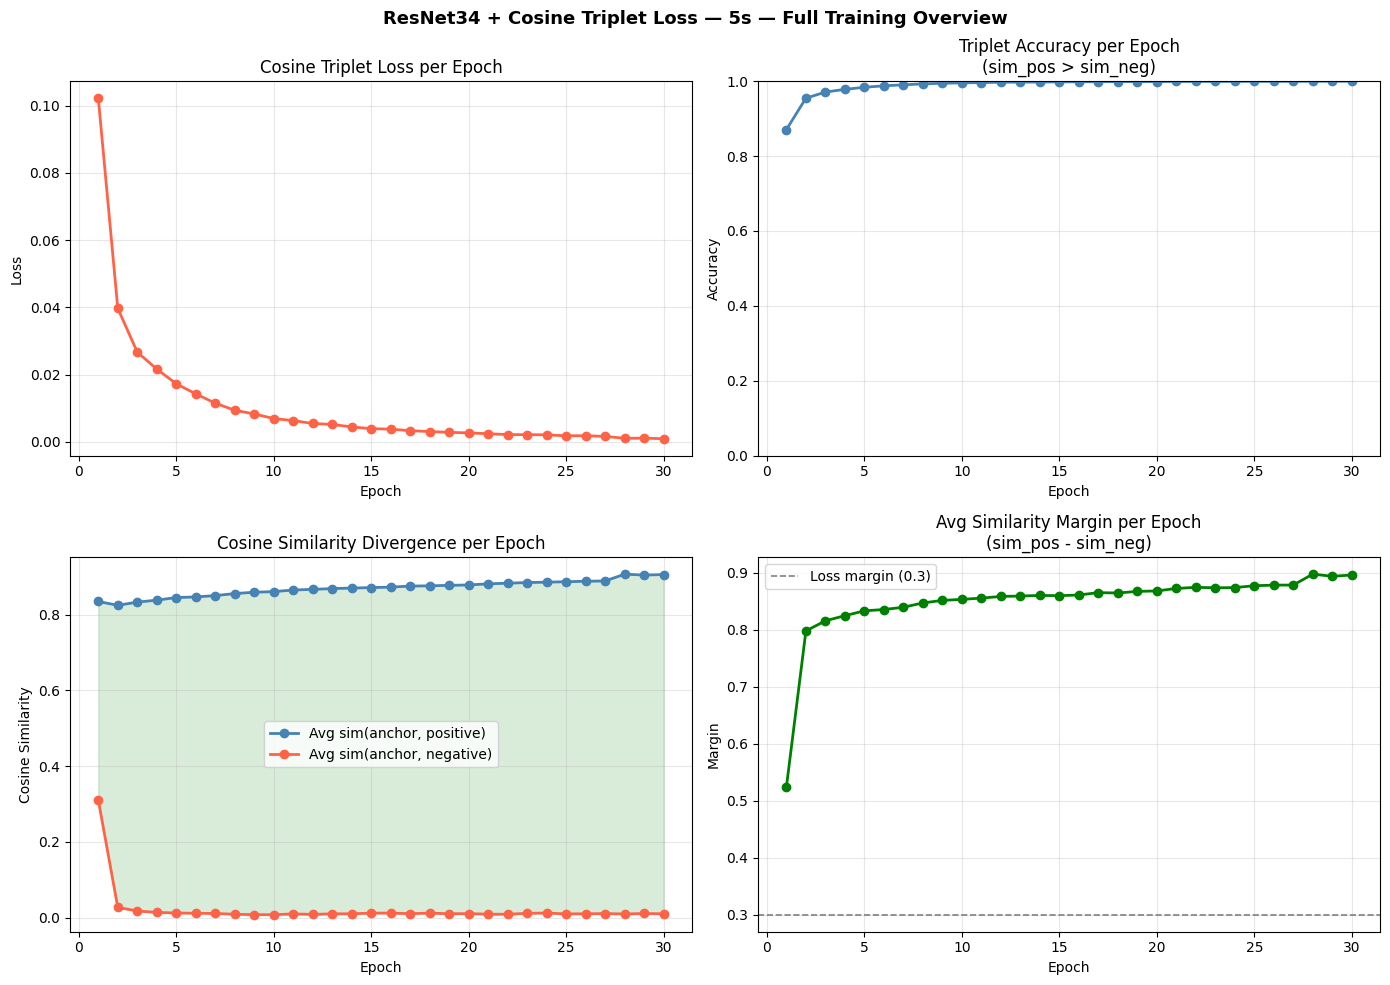

Saved → training_overview_cosine_triplet.png


In [7]:
import matplotlib.pyplot as plt

if loss_history:
    epochs_range = range(1, len(loss_history) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('ResNet34 + Cosine Triplet Loss — 5s — Full Training Overview', fontsize=13, fontweight='bold')

    axes[0, 0].plot(epochs_range, loss_history, marker='o', color='tomato', linewidth=2)
    axes[0, 0].set_title('Cosine Triplet Loss per Epoch')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(epochs_range, acc_history, marker='o', color='steelblue', linewidth=2)
    axes[0, 1].set_title('Triplet Accuracy per Epoch\n(sim_pos > sim_neg)')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_ylim(0, 1); axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(epochs_range, sim_pos_history, marker='o', color='steelblue', linewidth=2, label='Avg sim(anchor, positive)')
    axes[1, 0].plot(epochs_range, sim_neg_history, marker='o', color='tomato', linewidth=2, label='Avg sim(anchor, negative)')
    axes[1, 0].fill_between(epochs_range, sim_pos_history, sim_neg_history, alpha=0.15, color='green')
    axes[1, 0].set_title('Cosine Similarity Divergence per Epoch')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Cosine Similarity')
    axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

    margin_history = [p - n for p, n in zip(sim_pos_history, sim_neg_history)]
    axes[1, 1].plot(epochs_range, margin_history, marker='o', color='green', linewidth=2)
    axes[1, 1].axhline(y=0.3, color='gray', linestyle='--', linewidth=1.2, label='Loss margin (0.3)')
    axes[1, 1].set_title('Avg Similarity Margin per Epoch\n(sim_pos - sim_neg)')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Margin')
    axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_overview_cosine_triplet.png', dpi=150)
    plt.show()
    print('Saved → training_overview_cosine_triplet.png')
else:
    print("No training history in checkpoint.")

## 🔍 Step 8: Pair Evaluation Dataset & Function

*Copied from `Resume ResNet34 Triplet Loss.ipynb` — the cell that previously failed due to missing file.*

In [8]:
import soundfile as sf
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

class SpeakerPairDataset(Dataset):
    def __init__(self, dataframe, mel_transform, amplitude_to_db):
        self.df              = dataframe
        self.mel_transform   = mel_transform
        self.amplitude_to_db = amplitude_to_db

    def __len__(self):
        return len(self.df)

    def load_audio(self, path):
        audio, sr = sf.read(path)
        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)
        audio = crop_or_pad(audio, is_train=False)   # centre-crop for eval
        audio = torch.tensor(audio).float().unsqueeze(0)
        return self.amplitude_to_db(self.mel_transform(audio))

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        mel1  = self.load_audio(row['path1_abs'])
        mel2  = self.load_audio(row['path2_abs'])
        label = torch.tensor(row['label']).float()
        return mel1, mel2, label


def evaluate_pairs(model, loader, device, label_name='Set', threshold=0.5):
    model.eval()
    correct = 0; total = 0
    same_sims, diff_sims = [], []
    with torch.no_grad():
        for mel1, mel2, labels in tqdm(loader, desc=f'Evaluating {label_name}'):
            mel1, mel2, labels = mel1.to(device), mel2.to(device), labels.to(device)
            emb1 = model(mel1); emb2 = model(mel2)
            sim   = F.cosine_similarity(emb1, emb2)
            preds = (sim > threshold).float()
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            for s, lbl in zip(sim.cpu().tolist(), labels.cpu().tolist()):
                (same_sims if lbl == 1 else diff_sims).append(s)
    acc = correct / total
    print(f'{label_name} Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    return acc, same_sims, diff_sims

print("Dataset class and evaluation function defined.")

Dataset class and evaluation function defined.


## ▶️ Step 9: Evaluate — Training Set

In [9]:
train_pair_dataset = SpeakerPairDataset(df, mel_transform, amplitude_to_db)
train_pair_loader  = DataLoader(train_pair_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Evaluating on {len(train_pair_dataset)} training pairs...")
train_acc, tr_same_sim, tr_diff_sim = evaluate_pairs(model, train_pair_loader, device, 'Training Set')

Evaluating on 50000 training pairs...


Evaluating Training Set: 100%|██████████| 3125/3125 [09:57<00:00,  5.23it/s]

Training Set Accuracy: 0.9784 (97.84%)


## ▶️ Step 10: Evaluate — Test Set

In [10]:
test_pair_dataset = SpeakerPairDataset(test_df, mel_transform, amplitude_to_db)
test_pair_loader  = DataLoader(test_pair_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Evaluating on {len(test_pair_dataset)} test pairs...")
test_acc, te_same_sim, te_diff_sim = evaluate_pairs(model, test_pair_loader, device, 'Test Set')

print(f"\nTrain Acc: {train_acc*100:.2f}%  |  Test Acc: {test_acc*100:.2f}%")
print(f"Generalisation Gap: {(train_acc - test_acc)*100:.2f}%")

Evaluating on 50000 test pairs...


Evaluating Test Set: 100%|██████████| 3125/3125 [06:41<00:00,  7.79it/s]

Test Set Accuracy: 0.9183 (91.83%)

Train Acc: 97.84%  |  Test Acc: 91.83%
Generalisation Gap: 6.01%


## 📊 Step 11: Accuracy Comparison Bar Chart

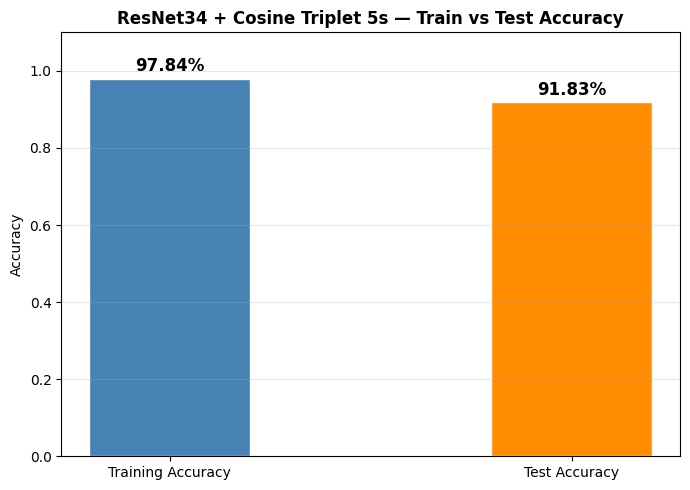

Saved → accuracy_comparison_cosine_triplet.png


In [11]:
plt.figure(figsize=(7, 5))
bars = plt.bar(['Training Accuracy', 'Test Accuracy'],
               [train_acc, test_acc],
               color=['steelblue', 'darkorange'], width=0.4, edgecolor='white')
for bar, val in zip(bars, [train_acc, test_acc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val*100:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('ResNet34 + Cosine Triplet 5s — Train vs Test Accuracy', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison_cosine_triplet.png', dpi=150)
plt.show()
print('Saved → accuracy_comparison_cosine_triplet.png')

## 📊 Step 12: Cosine Similarity Distribution — Training vs Test

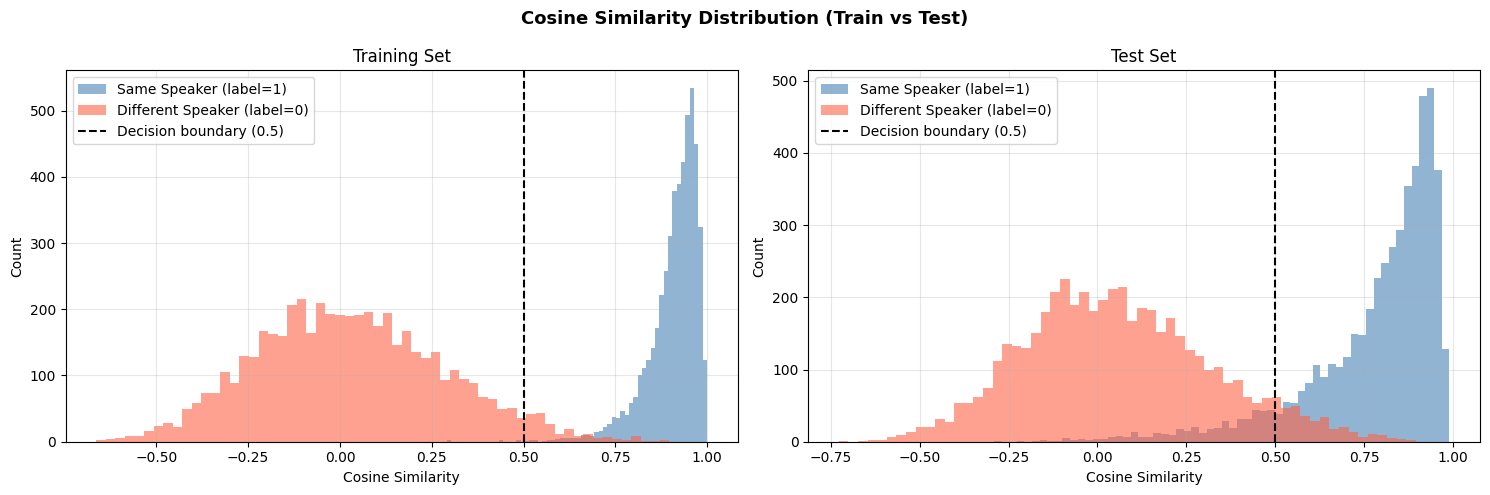

Saved → cosine_sim_dist_cosine_triplet.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Cosine Similarity Distribution (Train vs Test)', fontsize=13, fontweight='bold')

for ax, same, diff, title in [
    (axes[0], tr_same_sim[:5000], tr_diff_sim[:5000], 'Training Set'),
    (axes[1], te_same_sim[:5000], te_diff_sim[:5000], 'Test Set'),
]:
    ax.hist(same, bins=60, alpha=0.6, color='steelblue', label='Same Speaker (label=1)')
    ax.hist(diff, bins=60, alpha=0.6, color='tomato',    label='Different Speaker (label=0)')
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
    ax.set_title(title)
    ax.set_xlabel('Cosine Similarity'); ax.set_ylabel('Count')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cosine_sim_dist_cosine_triplet.png', dpi=150)
plt.show()
print('Saved → cosine_sim_dist_cosine_triplet.png')

## 🏁 Step 13: Final Summary

In [13]:
print('=' * 47)
print('  MODEL:  ResNet34 + Cosine Triplet Loss (5s)')
print('-' * 47)
print(f'  Total Epochs Completed : {last_epoch}')
if loss_history:
    print(f'  Final Triplet Loss     : {loss_history[-1]:.6f}')
print('-' * 47)
print(f'  Training Accuracy  : {train_acc*100:.2f}%')
print(f'  Test Accuracy      : {test_acc*100:.2f}%')
print(f'  Generalisation Gap : {(train_acc - test_acc)*100:.2f}%')
print('=' * 47)
print('Saved files:')
print('  training_overview_cosine_triplet.png')
print('  accuracy_comparison_cosine_triplet.png')
print('  cosine_sim_dist_cosine_triplet.png')

  MODEL:  ResNet34 + Cosine Triplet Loss (5s)
-----------------------------------------------
  Total Epochs Completed : 30
  Final Triplet Loss     : 0.000973
-----------------------------------------------
  Training Accuracy  : 97.84%
  Test Accuracy      : 91.83%
  Generalisation Gap : 6.01%
Saved files:
  training_overview_cosine_triplet.png
  accuracy_comparison_cosine_triplet.png
  cosine_sim_dist_cosine_triplet.png
